# Imports and constants

In [14]:
import toml
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import scipy.optimize as op

In [75]:
data_dir = "/net/debye/gmennella/randium/analysis/analysis_ref_data/raw_data"

outdata_dir = "/net/debye/gmennella/randium/analysis/analysis_ref_data"

beta_list = [
    0.0001, 
    0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 
    1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 
    2.0
]

beta_dict = {
    beta: idx for idx, beta in enumerate(beta_list)
}

# Functions

In [16]:
def stretch_exponential(t, A, tau, alpha):

    return A * np.exp(-(t/tau) ** alpha)

# Data analysis w/ CPU:

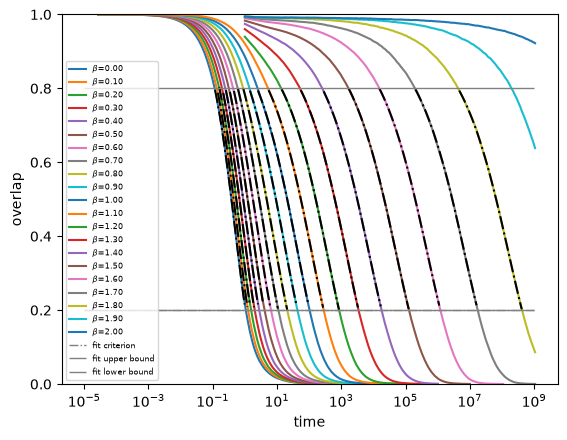

In [67]:
# At what time stitch CPU and GPU data.
stitch_time = 10_000
# Criterion to select the curves to analyse.
Q_criterion = 0.2
# Overlap range of values to fit.
Q_min, Q_max = 0.2, 0.8

# Initial guess for fit params.
p0 = [1.0, 0.5, 0.9]

# Storage for fit results.
beta_fit_list = []
A_fit_list = []
tau_fit_list = []
alpha_fit_list = []

# Used to select when to use cpu values.
beta_cpu = 1.1

for idx, beta in enumerate(beta_list):

    fname = f'192x192beta{beta:1.4f}'

    # Load metadata.
    metadata = toml.load(data_dir + f'/cpu_{fname}.toml')
    N = metadata['N']

    # Load CPU data.
    if beta <= beta_cpu:

        cpu_data = pd.read_csv(data_dir + f'/cpu_{fname}.csv')
        cpu_time_list = np.array(cpu_data['time'])
        cpu_overlap_list = np.array(cpu_data['particle_overlap'])

        cpu_Q_list = (cpu_overlap_list - 1 / N) / (1 - 1 / N)

    # Only use GPU data.
    else:
        cpu_time_list = cpu_Q_list = []

    # Load GPU data.
    gpu_data = pd.read_csv(data_dir + f'/gpu_{fname}.csv')
    gpu_time_list = np.array(gpu_data['time'])
    gpu_overlap_list = np.array(gpu_data['particle_overlap'])

    gpu_Q_list = (gpu_overlap_list - 1 / N) / (1 - 1 / N)

    if beta <= beta_cpu:
        gpu_mask = (gpu_time_list > stitch_time)
    else:
        gpu_mask = np.ones_like(gpu_time_list, dtype=bool)
    

    # Stitch data together
    time_list = np.concatenate(
        [cpu_time_list, gpu_time_list[gpu_mask]]
    )
    Q_list = np.concatenate(
        [cpu_Q_list, gpu_Q_list[gpu_mask]]
    )

    # Plot.
    plt.plot(
        time_list, Q_list,
        label=f'$\\beta$={beta:1.2f}',
    )

    # Fit.
    if min(Q_list) < Q_criterion:

        fit_mask = (Q_list > Q_min) & (Q_list < Q_max)
        time_fit_list = time_list[fit_mask]
        Q_fit_list = Q_list[fit_mask]

        popt, pcov = op.curve_fit(
            stretch_exponential,
            time_fit_list,
            Q_fit_list,
            p0=p0,
            bounds=(
                [.8, 0., 0.],
                [1.2, np.inf, 1.]
            )
        )

        A, tau, alpha = popt
        beta_fit_list.append(beta)
        A_fit_list.append(A)
        tau_fit_list.append(tau)
        alpha_fit_list.append(alpha)

        # Updated p0 to last popt found.
        p0 = popt

        # Fit plot.
        plt.plot(
            time_fit_list, 
            stretch_exponential(
                time_fit_list,
                A=A, tau=tau, alpha=alpha
            ),
            color='black',
            linestyle='-.'
        )


# ===== Plot =====
plt.hlines(
    Q_criterion, xmin=10**(-5), xmax=10**9,
    label='fit criterion',
    colors='gray',
    linestyles='-.',
    linewidth=1
)
plt.hlines(
    Q_max, xmin=10**(-5), xmax=10**9,
    label='fit upper bound',
    colors='gray',
    linewidth=1
)
plt.hlines(
    Q_min, xmin=10**(-5), xmax=10**9,
    label='fit lower bound',
    colors='gray',
    linewidth=1
)

plt.xscale("log")

plt.ylim(0., 1.)

plt.xlabel("time")
plt.ylabel("overlap")
plt.legend(
    fontsize=6,
    loc='lower left',
)

(0.0, 1.0)

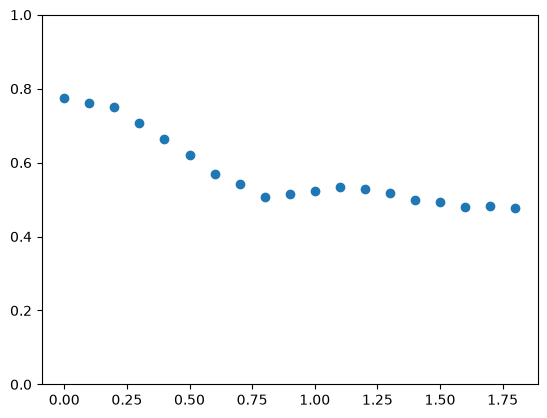

In [68]:
plt.plot(
    beta_fit_list, alpha_fit_list, 'o'
)

plt.ylim(0., 1.)

## Save fit results

In [76]:
save_fit_result_filepath = f"{outdata_dir}/ref_fit_result_all.dat"

save_fit_header = (
    "Fit result for stretched exponent of the original square "
    "lattice results (made by Guglielmo).\n"
    "beta | A | tau | alpha"
)

np.savetxt(
    fname=save_fit_result_filepath,
    X=[
        beta_fit_list,
        A_fit_list,
        tau_fit_list,
        alpha_fit_list
    ]
)

# Reference data

(4, 19)


Text(0, 0.5, '$\\alpha$')

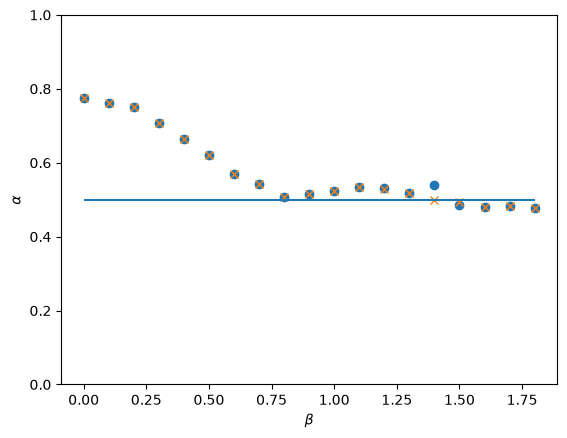

In [69]:
ref_data_filepath = "/net/debye/gmennella/randium/analysis/analysis_ref_data/fit_result_all.dat"

ref_data = np.loadtxt(ref_data_filepath)

ref_beta_list = ref_data[0]
ref_A_list = ref_data[1]
ref_t0_list = ref_data[2]
ref_alpha_list = ref_data[3]

print(ref_data.shape)

plt.plot(ref_beta_list, ref_alpha_list, 'o', label='ref fit')
plt.plot(beta_fit_list, alpha_fit_list, 'x', label='my fit')

plt.hlines(.5, min(ref_beta_list), max(ref_beta_list))

plt.ylim(0., 1.)

plt.xlabel("$\\beta$")
plt.ylabel("$\\alpha$")